# Understanding and Evaluating Imbalanced Data

## Datasets and Setup

### Dataset Choice

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import seaborn as sns
from pathlib import Path
import sys
import warnings
warnings.filterwarnings("ignore")

sys.path.insert(0, str(Path().resolve().parent))
from config import DATA_RAW, DATA_PROCESSED, FIGURES, RANDOM_SEED

sns.set_theme(style="whitegrid", palette="muted")
rng = np.random.default_rng(RANDOM_SEED)

from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import Pipeline
from sklearn.model_selection import StratifiedKFold, train_test_split

# ══════════════════════════════════════════════════════════════════════════
# Dataset A — Credit Card Fraud (extreme imbalance)
# ══════════════════════════════════════════════════════════════════════════
cc_url = (
    "https://storage.googleapis.com/download.tensorflow.org"
    "/data/creditcard.csv"
)
df_cc = pd.read_csv(cc_url)

X_cc = df_cc.drop(columns=["Class", "Time"])
y_cc = df_cc["Class"]

# Log-scale Amount to compress skew
X_cc = X_cc.copy()
X_cc["Amount"] = np.log1p(X_cc["Amount"])

print("=== Credit Card Fraud ===")
print(f"  Total observations : {len(y_cc):,}")
print(f"  Fraudulent         : {y_cc.sum():,}  ({y_cc.mean()*100:.3f}%)")
print(f"  Legitimate         : {(1-y_cc).sum():,}  ({(1-y_cc).mean()*100:.3f}%)")
print(f"  Imbalance ratio    : {(1-y_cc).sum() / y_cc.sum():.0f}:1")
print(f"  Features           : {X_cc.shape[1]}")

# ══════════════════════════════════════════════════════════════════════════
# Dataset B — Mammography (moderate imbalance, medical context)
# OpenML dataset ID 310 — Woods Mammography (11,183 obs, 6 features, ~2.3% positive)
# Three loading methods in order of preference; the first that succeeds is used.
# ══════════════════════════════════════════════════════════════════════════

X_mammo = None
y_mammo = None

# ── Method 1: scikit-learn fetch_openml (recommended, no extra dependencies) ──
try:
    from sklearn.datasets import fetch_openml
    mammo_bunch = fetch_openml(
        data_id=310,          # OpenML dataset ID for Woods Mammography
        as_frame=True,
        parser="auto",
    )
    X_mammo = mammo_bunch.data.copy().reset_index(drop=True)
    X_mammo.columns = [f"feat_{i}" for i in range(X_mammo.shape[1])]
    X_mammo = X_mammo.astype(float)
    # Target is '-1' (benign) / '1' (malignant) as strings
    y_mammo = (mammo_bunch.target.astype(str).str.strip() == "1").astype(int)
    y_mammo = y_mammo.rename("malignant").reset_index(drop=True)
    print("Mammography loaded via sklearn fetch_openml  ✓")

except Exception as e1:
    print(f"Method 1 failed ({e1}); trying Method 2...")

    # ── Method 2: direct ARFF download from OpenML ────────────────────────
    try:
        import urllib.request
        from io import StringIO
        arff_url = (
            "https://www.openml.org/data/v1/download/52214/mammography.arff"
        )
        with urllib.request.urlopen(arff_url, timeout=60) as resp:
            arff_text = resp.read().decode("utf-8")

        # Parse ARFF manually (header + data)
        lines = arff_text.splitlines()
        data_start = next(
            i for i, l in enumerate(lines) if l.strip().upper() == "@DATA"
        ) + 1
        data_lines = [l for l in lines[data_start:] if l.strip() and not l.startswith("%")]

        rows = []
        for line in data_lines:
            parts = [p.strip().strip("'") for p in line.split(",")]
            rows.append(parts)

        n_feat = len(rows[0]) - 1
        df_arff = pd.DataFrame(rows, columns=[f"feat_{i}" for i in range(n_feat)] + ["target"])
        X_mammo = df_arff[[f"feat_{i}" for i in range(n_feat)]].astype(float)
        y_mammo = (df_arff["target"].str.strip() == "1").astype(int).rename("malignant")
        print("Mammography loaded via direct ARFF download  ✓")

    except Exception as e2:
        print(f"Method 2 failed ({e2}); trying Method 3...")

        # ── Method 3: imbalanced-learn built-in fetch_datasets ────────────
        try:
            from imblearn.datasets import fetch_datasets
            mammo_data = fetch_datasets()["mammography"]
            X_mammo = pd.DataFrame(
                mammo_data.data,
                columns=[f"feat_{i}" for i in range(mammo_data.data.shape[1])]
            )
            y_mammo = pd.Series(
                (mammo_data.target == 1).astype(int), name="malignant"
            )
            print("Mammography loaded via imbalanced-learn fetch_datasets  ✓")

        except Exception as e3:
            raise RuntimeError(
                "All three mammography loading methods failed.\n"
                f"  Method 1 (fetch_openml): {e1}\n"
                f"  Method 2 (ARFF download): {e2}\n"
                f"  Method 3 (imblearn):      {e3}\n"
                "Install imbalanced-learn: pip install imbalanced-learn"
            ) from e3

print("\n=== Mammography ===")
print(f"  Total observations : {len(y_mammo):,}")
print(f"  Malignant          : {y_mammo.sum():,}  ({y_mammo.mean()*100:.2f}%)")
print(f"  Benign             : {(1-y_mammo).sum():,}  ({(1-y_mammo).mean()*100:.2f}%)")
print(f"  Imbalance ratio    : {(1-y_mammo).sum() / y_mammo.sum():.0f}:1")
print(f"  Features           : {X_mammo.shape[1]}")

=== Credit Card Fraud ===
  Total observations : 284,807
  Fraudulent         : 492  (0.173%)
  Legitimate         : 284,315  (99.827%)
  Imbalance ratio    : 578:1
  Features           : 29
Mammography loaded via sklearn fetch_openml  ✓

=== Mammography ===
  Total observations : 11,183
  Malignant          : 260  (2.32%)
  Benign             : 10,923  (97.68%)
  Imbalance ratio    : 42:1
  Features           : 6


### Train / Test Split and Preprocessing

In [2]:
# ── Stratified split — preserves class proportions in both sets ───────────
# Credit card fraud
X_cc_tr, X_cc_te, y_cc_tr, y_cc_te = train_test_split(
    X_cc, y_cc, test_size=0.2, random_state=RANDOM_SEED, stratify=y_cc
)

# Mammography
X_mm_tr, X_mm_te, y_mm_tr, y_mm_te = train_test_split(
    X_mammo, y_mammo, test_size=0.2, random_state=RANDOM_SEED, stratify=y_mammo
)

# ── Scaling (fit only on training data) ───────────────────────────────────
scaler_cc = StandardScaler()
X_cc_tr_sc = scaler_cc.fit_transform(X_cc_tr)
X_cc_te_sc = scaler_cc.transform(X_cc_te)

scaler_mm = StandardScaler()
X_mm_tr_sc = scaler_mm.fit_transform(X_mm_tr)
X_mm_te_sc = scaler_mm.transform(X_mm_te)

print("Credit card fraud — train/test split:")
print(f"  Train: {len(y_cc_tr):,} obs, {y_cc_tr.sum()} fraud ({y_cc_tr.mean()*100:.3f}%)")
print(f"  Test : {len(y_cc_te):,} obs, {y_cc_te.sum()} fraud ({y_cc_te.mean()*100:.3f}%)")

print("\nMammography — train/test split:")
print(f"  Train: {len(y_mm_tr):,} obs, {y_mm_tr.sum()} malignant ({y_mm_tr.mean()*100:.2f}%)")
print(f"  Test : {len(y_mm_te):,} obs, {y_mm_te.sum()} malignant ({y_mm_te.mean()*100:.2f}%)")

Credit card fraud — train/test split:
  Train: 227,845 obs, 394 fraud (0.173%)
  Test : 56,962 obs, 98 fraud (0.172%)

Mammography — train/test split:
  Train: 8,946 obs, 208 malignant (2.33%)
  Test : 2,237 obs, 52 malignant (2.32%)


### Saving Processed Data

In [3]:
# ── Save shared state for Chapter 9 ──────────────────────────────────────
import numpy as np
from pathlib import Path

_ch08_out = Path(DATA_PROCESSED)
_ch08_out.mkdir(parents=True, exist_ok=True)

np.save(_ch08_out / 'X_cc_tr_sc.npy', X_cc_tr_sc)
np.save(_ch08_out / 'X_cc_te_sc.npy', X_cc_te_sc)
np.save(_ch08_out / 'X_mm_tr_sc.npy', X_mm_tr_sc)
np.save(_ch08_out / 'X_mm_te_sc.npy', X_mm_te_sc)

y_cc_tr.to_pickle(_ch08_out / 'y_cc_tr.pkl')
y_cc_te.to_pickle(_ch08_out / 'y_cc_te.pkl')
y_mm_tr.to_pickle(_ch08_out / 'y_mm_tr.pkl')
y_mm_te.to_pickle(_ch08_out / 'y_mm_te.pkl')

print(f'Shared arrays saved to  : {_ch08_out}')
print('  X_cc_tr_sc.npy  X_cc_te_sc.npy')
print('  X_mm_tr_sc.npy  X_mm_te_sc.npy')
print('  y_cc_tr.pkl     y_cc_te.pkl')
print('  y_mm_tr.pkl     y_mm_te.pkl')


Shared arrays saved to  : F:\project-workspace\quarto-book\data-mode-book\data-model-code\data\processed
  X_cc_tr_sc.npy  X_cc_te_sc.npy
  X_mm_tr_sc.npy  X_mm_te_sc.npy
  y_cc_tr.pkl     y_cc_te.pkl
  y_mm_tr.pkl     y_mm_te.pkl


## Understanding Class Imbalance

### The Accuracy Paradox

In [4]:
from sklearn.linear_model import LogisticRegression
from sklearn.dummy import DummyClassifier
from sklearn.metrics import (
    accuracy_score, confusion_matrix, classification_report,
    precision_score, recall_score, f1_score,
    roc_auc_score, average_precision_score,
    matthews_corrcoef, ConfusionMatrixDisplay
)

# ── Majority-class baseline ────────────────────────────────────────────────
dummy = DummyClassifier(strategy="most_frequent")
dummy.fit(X_cc_tr_sc, y_cc_tr)
y_dummy = dummy.predict(X_cc_te_sc)

# ── Vanilla logistic regression (no imbalance correction) ─────────────────
lr_vanilla = LogisticRegression(max_iter=1000, random_state=RANDOM_SEED)
lr_vanilla.fit(X_cc_tr_sc, y_cc_tr)
y_lr_pred = lr_vanilla.predict(X_cc_te_sc)
y_lr_prob  = lr_vanilla.predict_proba(X_cc_te_sc)[:, 1]

def print_metrics(y_true, y_pred, y_prob, label):
    tn, fp, fn, tp = confusion_matrix(y_true, y_pred).ravel()
    print(f"\n{'─'*55}")
    print(f"  {label}")
    print(f"{'─'*55}")
    print(f"  Accuracy    : {accuracy_score(y_true, y_pred):.5f}")
    print(f"  Precision   : {precision_score(y_true, y_pred, zero_division=0):.4f}")
    print(f"  Recall      : {recall_score(y_true, y_pred, zero_division=0):.4f}")
    print(f"  F1 Score    : {f1_score(y_true, y_pred, zero_division=0):.4f}")
    print(f"  MCC         : {matthews_corrcoef(y_true, y_pred):.4f}")
    if y_prob is not None:
        print(f"  ROC-AUC     : {roc_auc_score(y_true, y_prob):.4f}")
        print(f"  PR-AUC      : {average_precision_score(y_true, y_prob):.4f}")
    print(f"  Confusion   : TP={tp}, FP={fp}, FN={fn}, TN={tn}")

print_metrics(y_cc_te, y_dummy,   None,      "Majority-class baseline")
print_metrics(y_cc_te, y_lr_pred, y_lr_prob, "Logistic Regression (no correction)")


───────────────────────────────────────────────────────
  Majority-class baseline
───────────────────────────────────────────────────────
  Accuracy    : 0.99828
  Precision   : 0.0000
  Recall      : 0.0000
  F1 Score    : 0.0000
  MCC         : 0.0000
  Confusion   : TP=0, FP=0, FN=98, TN=56864

───────────────────────────────────────────────────────
  Logistic Regression (no correction)
───────────────────────────────────────────────────────
  Accuracy    : 0.99917
  Precision   : 0.8312
  Recall      : 0.6531
  F1 Score    : 0.7314
  MCC         : 0.7364
  ROC-AUC     : 0.9586
  PR-AUC      : 0.7376
  Confusion   : TP=64, FP=13, FN=34, TN=56851


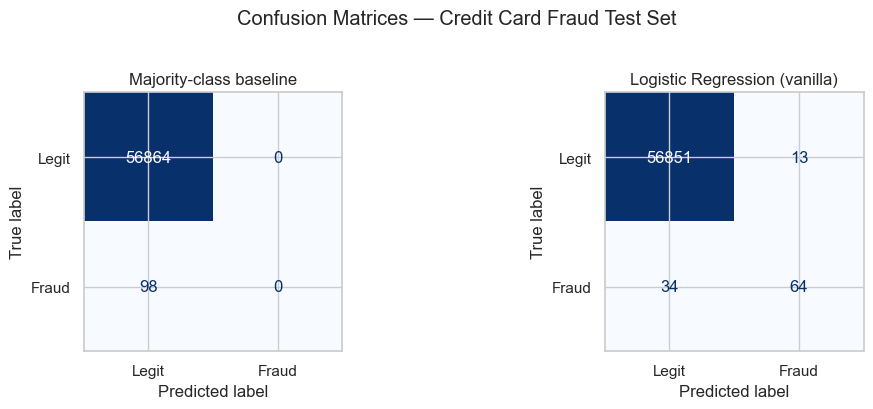

In [5]:
# ── Confusion matrix visualisation ────────────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(11, 4))
for ax, (y_pred, title) in zip(axes, [
    (y_dummy,   "Majority-class baseline"),
    (y_lr_pred, "Logistic Regression (vanilla)")
]):
    cm = confusion_matrix(y_cc_te, y_pred)
    disp = ConfusionMatrixDisplay(cm, display_labels=["Legit", "Fraud"])
    disp.plot(ax=ax, colorbar=False, cmap="Blues")
    ax.set_title(title)

plt.suptitle("Confusion Matrices — Credit Card Fraud Test Set", y=1.02)
plt.tight_layout()
plt.savefig(FIGURES / "ch08_baseline_confusion.png", dpi=150, bbox_inches="tight")
plt.show()

### Why Standard Loss Functions Fail

### Precision-Recall Curves

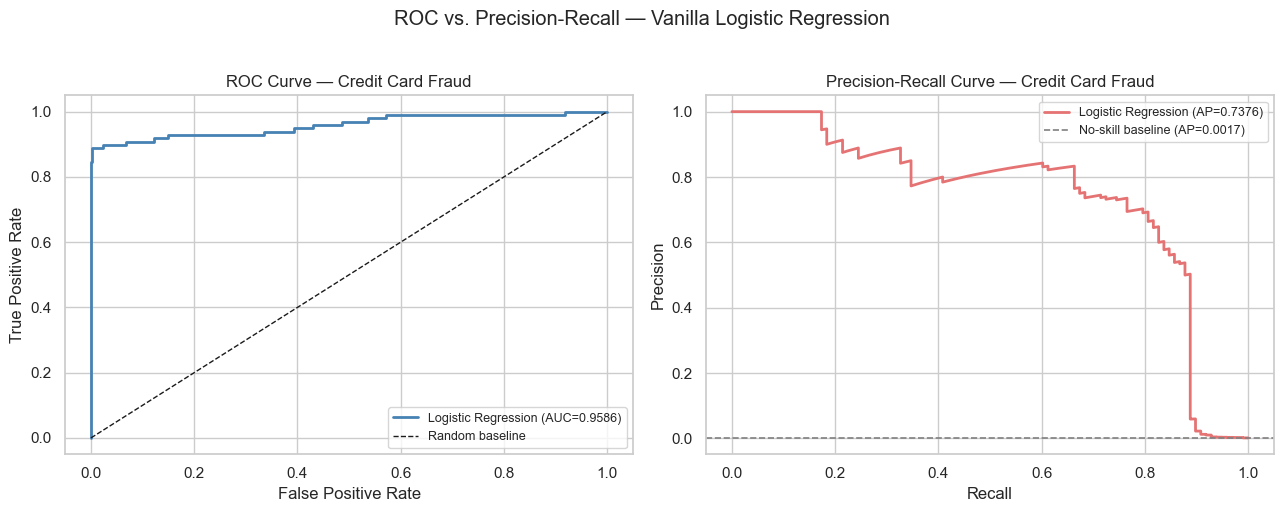

Positive class rate (no-skill AP baseline): 0.0017
Logistic Regression ROC-AUC : 0.9586
Logistic Regression PR-AUC  : 0.7376
PR-AUC / no-skill ratio     : 428.7×


In [6]:
from sklearn.metrics import (
    PrecisionRecallDisplay, RocCurveDisplay,
    precision_recall_curve, roc_curve
)

fig, axes = plt.subplots(1, 2, figsize=(13, 5))

# ── ROC Curve ─────────────────────────────────────────────────────────────
fpr, tpr, _ = roc_curve(y_cc_te, y_lr_prob)
roc_auc = roc_auc_score(y_cc_te, y_lr_prob)
axes[0].plot(fpr, tpr, color="steelblue", lw=2,
             label=f"Logistic Regression (AUC={roc_auc:.4f})")
axes[0].plot([0, 1], [0, 1], "k--", lw=1, label="Random baseline")
axes[0].set_xlabel("False Positive Rate")
axes[0].set_ylabel("True Positive Rate")
axes[0].set_title("ROC Curve — Credit Card Fraud")
axes[0].legend(fontsize=9)

# ── Precision-Recall Curve ────────────────────────────────────────────────
prec, rec, thresh = precision_recall_curve(y_cc_te, y_lr_prob)
pr_auc = average_precision_score(y_cc_te, y_lr_prob)
axes[1].plot(rec, prec, color="#E57373", lw=2,
             label=f"Logistic Regression (AP={pr_auc:.4f})")
axes[1].axhline(y_cc_te.mean(), color="gray", lw=1.2, linestyle="--",
                label=f"No-skill baseline (AP={y_cc_te.mean():.4f})")
axes[1].set_xlabel("Recall")
axes[1].set_ylabel("Precision")
axes[1].set_title("Precision-Recall Curve — Credit Card Fraud")
axes[1].legend(fontsize=9)

plt.suptitle("ROC vs. Precision-Recall — Vanilla Logistic Regression", y=1.02)
plt.tight_layout()
plt.savefig(FIGURES / "ch08_roc_pr.png", dpi=150, bbox_inches="tight")
plt.show()

print(f"Positive class rate (no-skill AP baseline): {y_cc_te.mean():.4f}")
print(f"Logistic Regression ROC-AUC : {roc_auc:.4f}")
print(f"Logistic Regression PR-AUC  : {pr_auc:.4f}")
print(f"PR-AUC / no-skill ratio     : {pr_auc / y_cc_te.mean():.1f}×")